In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("Employee data.csv")
df.head()

,id,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority
0,1.0,Male,1952-02-03,15,Manager,57000.0,27000.0,98.0,144.0,No
1,2.0,Male,1958-05-23,16,Clerical,40200.0,18750.0,98.0,36.0,No
2,3.0,Female,1929-07-26,12,Clerical,21450.0,12000.0,98.0,381.0,No
3,4.0,Female,1947-04-15,8,Clerical,21900.0,13200.0,98.0,190.0,No
4,5.0,Male,1955-02-09,15,Clerical,45000.0,21000.0,98.0,138.0,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        474 non-null    float64
 1   gender    474 non-null    object 
 2   bdate     473 non-null    object 
 3   educ      474 non-null    int64  
 4   jobcat    474 non-null    object 
 5   salary    474 non-null    float64
 6   salbegin  474 non-null    float64
 7   jobtime   474 non-null    float64
 8   prevexp   474 non-null    object 
 9   minority  474 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 37.2+ KB


In [6]:
df.describe()

,id,educ,salary,salbegin,jobtime
count,474.000000,474.000000,474.000000,474.000000,474.000000
mean,237.500000,13.491561,34419.567511,17016.086498,81.109705
std,136.976275,2.884846,17075.661465,7870.638154,10.060945
min,1.000000,8.000000,15750.000000,9000.000000,63.000000
25%,119.250000,12.000000,24000.000000,12487.500000,72.000000
50%,237.500000,12.000000,28875.000000,15000.000000,81.000000
75%,355.750000,15.000000,36937.500000,17490.000000,90.000000
max,474.000000,21.000000,135000.000000,79980.000000,98.000000


In [7]:
df.columns

Index(['id', 'gender', 'bdate', 'educ', 'jobcat', 'salary', 'salbegin',
       'jobtime', 'prevexp', 'minority'],
      dtype='object')

### Check Object & Number Columns

In [8]:
df.select_dtypes(include='object').columns

Index(['gender', 'bdate', 'jobcat', 'prevexp', 'minority'], dtype='object')

In [9]:
df.select_dtypes(include='number').columns

Index(['id', 'educ', 'salary', 'salbegin', 'jobtime'], dtype='object')

### Convert Object to Number

In [11]:
df['prevexp'] = pd.to_numeric(df['prevexp'], errors='coerce')

In [12]:
df.select_dtypes(include='number').columns

Index(['id', 'educ', 'salary', 'salbegin', 'jobtime', 'prevexp'], dtype='object')

In [30]:
df.isnull().sum()

id           0
gender       0
bdate        1
educ         0
jobcat       0
salary       0
salbegin     0
jobtime      0
prevexp     24
minority     0
dtype: int64

In [13]:
df.duplicated().sum()

0

# Drop Irrelevant Features

In [32]:
df = df.drop(columns=['id'])

In [19]:
df.head(1)

,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority
0,Male,1952-02-03,15,Manager,57000.0,27000.0,98.0,144.0,No


# Convert date and extract features

In [14]:
df['bdate'] = pd.to_datetime(df['bdate'])
current_year = 2000
df['age'] = current_year - df['bdate'].dt.year
df = df.drop(columns=['bdate'])

In [15]:
df.head(1)

,id,gender,educ,jobcat,salary,salbegin,jobtime,prevexp,minority,age
0,1.0,Male,15,Manager,57000.0,27000.0,98.0,144.0,No,48.0


### Handle missing Values in 'Object' & 'Num' Data type

In [17]:
from sklearn.impute import SimpleImputer
num_cols = df.select_dtypes(include='number').columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [18]:
cat_cols = ['gender', 'jobcat', 'minority']
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [40]:
df.isnull().sum()

gender      0
educ        0
jobcat      0
salary      0
salbegin    0
jobtime     0
prevexp     0
minority    0
age         0
dtype: int64

In [19]:
df.describe()

,id,educ,salary,salbegin,jobtime,prevexp,age
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,237.500000,13.491561,34419.567511,17016.086498,81.109705,98.848101,43.660338
std,136.976275,2.884846,17075.661465,7870.638154,10.060945,102.625606,11.774512
min,1.000000,8.000000,15750.000000,9000.000000,63.000000,2.000000,29.000000
25%,119.250000,12.000000,24000.000000,12487.500000,72.000000,25.000000,35.000000
50%,237.500000,12.000000,28875.000000,15000.000000,81.000000,59.000000,38.000000
75%,355.750000,15.000000,36937.500000,17490.000000,90.000000,138.750000,52.000000
max,474.000000,21.000000,135000.000000,79980.000000,98.000000,476.000000,71.000000


In [20]:
import seaborn as sns

<Axes: >

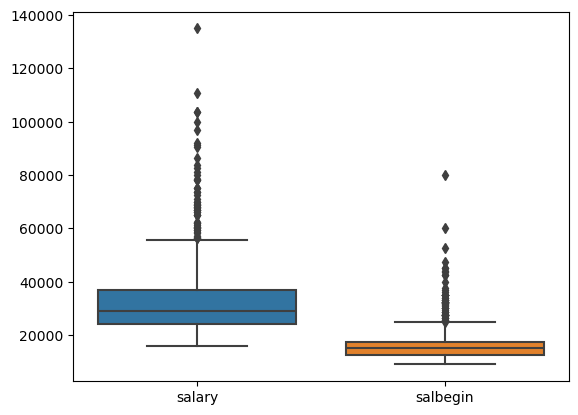

In [22]:
sns.boxplot(df[['salary', 'salbegin']])

<Axes: >

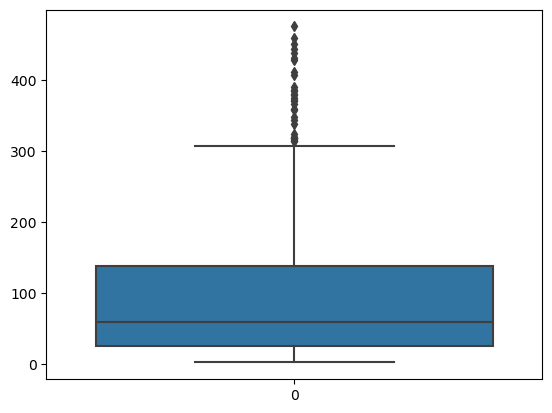

In [23]:
sns.boxplot(df['prevexp'])

<Axes: >

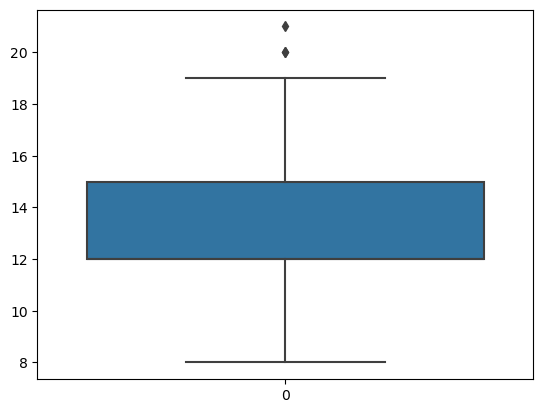

In [21]:
sns.boxplot(df['educ'])

<Axes: >

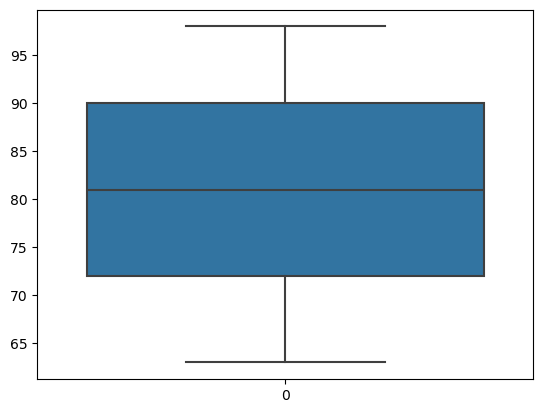

In [24]:
sns.boxplot(df['jobtime'])

In [26]:
import numpy as np

## Handle outliers (IQR capping)

In [27]:
for col in ['salary', 'salbegin', 'prevexp']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)


# Feature Engineering

### Salary growth feature

In [28]:
df['salary_growth'] = df['salary'] - df['salbegin']

### Experience ratio feature

In [29]:
df['experience_ratio'] = df['prevexp'] / (df['jobtime'] + 1)

In [30]:
df.head(3)

,id,gender,educ,jobcat,salary,salbegin,jobtime,prevexp,minority,age,salary_growth,experience_ratio
0,1.0,Male,15.0,Manager,56343.75,24993.75,98.0,144.000,No,48.0,31350.0,1.454545
1,2.0,Male,16.0,Clerical,40200.00,18750.00,98.0,36.000,No,42.0,21450.0,0.363636
2,3.0,Female,12.0,Clerical,21450.00,12000.00,98.0,309.375,No,71.0,9450.0,3.125000


In [33]:
col = df.select_dtypes(include='number').columns
corr = df[col].corr()
corr

,id,educ,salary,salbegin,jobtime,prevexp,age,salary_growth,experience_ratio
id,1.000000,-0.057212,-0.092842,0.008659,-0.998186,0.002473,-0.053260,-0.141837,0.126775
educ,-0.057212,1.000000,0.702678,0.697331,0.047379,-0.254200,-0.282376,0.639425,-0.267531
salary,-0.092842,0.702678,1.000000,0.892866,0.080166,-0.151585,-0.204632,0.966614,-0.164784
salbegin,0.008659,0.697331,0.892866,1.000000,-0.022157,0.001466,-0.067273,0.747666,-0.000424
jobtime,-0.998186,0.047379,0.080166,-0.022157,1.000000,-0.002580,0.052445,0.130826,-0.127296
prevexp,0.002473,-0.254200,-0.151585,0.001466,-0.002580,1.000000,0.806354,-0.224372,0.985877
age,-0.053260,-0.282376,-0.204632,-0.067273,0.052445,0.806354,1.000000,-0.263484,0.796435
salary_growth,-0.141837,0.639425,0.966614,0.747666,0.130826,-0.224372,-0.263484,1.000000,-0.242760
experience_ratio,0.126775,-0.267531,-0.164784,-0.000424,-0.127296,0.985877,0.796435,-0.242760,1.000000


## Encoding categorical variables

In [30]:
df.head(3)

,id,gender,educ,jobcat,salary,salbegin,jobtime,prevexp,minority,age,salary_growth,experience_ratio
0,1.0,Male,15.0,Manager,56343.75,24993.75,98.0,144.000,No,48.0,31350.0,1.454545
1,2.0,Male,16.0,Clerical,40200.00,18750.00,98.0,36.000,No,42.0,21450.0,0.363636
2,3.0,Female,12.0,Clerical,21450.00,12000.00,98.0,309.375,No,71.0,9450.0,3.125000


In [34]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [35]:
# Label Encoding
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['minority'] = le.fit_transform(df['minority'])

In [36]:
# One Hot Encoding
df = pd.get_dummies(df, columns=['jobcat'])

In [38]:
df.drop('id', axis=1, inplace=True)

In [39]:
df.head(2)

,gender,educ,salary,salbegin,jobtime,prevexp,minority,age,salary_growth,experience_ratio,jobcat_Clerical,jobcat_Custodial,jobcat_Manager
0,1,15.0,56343.75,24993.75,98.0,144.0,0,48.0,31350.0,1.454545,False,False,True
1,1,16.0,40200.00,18750.00,98.0,36.0,0,42.0,21450.0,0.363636,True,False,False


### Feature Scaling

In [40]:
from sklearn.preprocessing import StandardScaler
sacled_col = ['educ', 'salbegin', 'jobtime', 'prevexp','salary_growth','experience_ratio' ]
scaler = StandardScaler()
df[sacled_col] = scaler.fit_transform(df[sacled_col])

In [41]:
df.head(2)

,gender,educ,salary,salbegin,jobtime,prevexp,minority,age,salary_growth,experience_ratio,jobcat_Clerical,jobcat_Custodial,jobcat_Manager
0,1,0.523436,56343.75,2.026817,1.680572,0.545342,0,48.0,1.860060,0.251387,False,False,True
1,1,0.870441,40200.00,0.644150,1.680572,-0.645015,0,42.0,0.612602,-0.708583,True,False,False


In [42]:
X = df.drop('salary', axis=1)
y = df['salary']

### Feature Selection
Remove low variance features:

### Train Test Aplit

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                            test_size=0.2, random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [51]:
y_pred

array([30000.  , 23850.  , 24000.  , 25200.  , 19200.  , 56343.75,
       34410.  , 34500.  , 22950.  , 26850.  , 29250.  , 51000.  ,
       34500.  , 31950.  , 27750.  , 43650.  , 34800.  , 27600.  ,
       26250.  , 33900.  , 32400.  , 56343.75, 34500.  , 28350.  ,
       20100.  , 36150.  , 56343.75, 38400.  , 23400.  , 56343.75,
       24900.  , 37500.  , 35550.  , 22950.  , 27450.  , 42300.  ,
       20550.  , 25500.  , 26400.  , 27750.  , 43410.  , 22050.  ,
       22350.  , 17700.  , 21600.  , 31950.  , 29400.  , 28050.  ,
       33900.  , 25200.  , 30750.  , 24600.  , 56343.75, 23400.  ,
       56343.75, 22500.  , 56343.75, 53125.  , 30000.  , 18450.  ,
       28950.  , 25650.  , 30750.  , 38700.  , 35250.  , 28500.  ,
       23700.  , 27300.  , 33900.  , 31650.  , 27300.  , 37800.  ,
       40800.  , 16350.  , 26100.  , 26250.  , 33300.  , 31200.  ,
       33900.  , 20700.  , 29700.  , 34500.  , 39900.  , 27600.  ,
       24300.  , 31050.  , 19800.  , 22950.  , 30900.  , 23250

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
mse = mean_squared_error(y_test, y_pred)
mse

4.267520558968839e-21